In [229]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np

latent_dim = 16
# Set the seed for reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

In [230]:
# A custom layer to sample from the latent space
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [244]:
def build_encoder(latent_dim):
    """
    Builds a deeper convolutional encoder network with more layers.
    """
    encoder_inputs = layers.Input(shape=(28, 28, 1))

    # Deeper convolutional blocks
    x = layers.Conv2D(32, 3, activation=tf.nn.leaky_relu, strides=2, padding="same")(encoder_inputs)
    x = layers.BatchNormalization()(x) # Added layer
    x = layers.Conv2D(64, 3, activation=tf.nn.leaky_relu, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x) # Added layer
    x = layers.Conv2D(128, 3, activation=tf.nn.leaky_relu, strides=1, padding="same")(x) # Added layer

    # Flatten the output to connect to the dense layers
    x = layers.Flatten()(x)
    # Increased the size of the dense layer for more capacity
    x = layers.Dense(64, activation=tf.nn.leaky_relu)(x)

    # Output layers for the latent distribution
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

    # Sampling layer
    z = Sampling()([z_mean, z_log_var])

    encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
    return encoder

# Let's instantiate it
encoder = build_encoder(latent_dim)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_89      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_123 (Conv2D) │ (None, 14, 14,    │        320 │ input_layer_89[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_123[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_124 (Conv2D) │ (None, 7, 7, 64)  │     18,496 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 64)  │        256 │ conv2d_124[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_125 (Conv2D) │ (None, 7, 7, 128) │     73,856 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_45          │ (None, 6272)      │          0 │ conv2d_125[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_123 (Dense)   │ (None, 64)        │    401,472 │ flatten_45[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      1,040 │ dense_123[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      1,040 │ dense_123[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_44         │ (None, 16)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 496,608 (1.89 MB)

 Trainable params: 496,416 (1.89 MB)

 Non-trainable params: 192 (768.00 B)

In [232]:
def build_decoder(latent_dim):
    """
    Builds a deeper convolutional decoder network to mirror the encoder.
    """
    latent_inputs = layers.Input(shape=(latent_dim,))

    # Deeper dense and reshaping blocks
    x = layers.Dense(64, activation=tf.nn.leaky_relu)(latent_inputs)
    # The shape now corresponds to the output of the deeper encoder's convolutions (7x7x128)
    x = layers.Dense(7 * 7 * 128, activation=tf.nn.leaky_relu)(x)
    x = layers.Reshape((7, 7, 128))(x)

    # Deeper transposed convolutional blocks
    x = layers.Conv2DTranspose(128, 3, activation=tf.nn.leaky_relu, strides=1, padding="same")(x) # Added layer
    x = layers.BatchNormalization()(x) # Added layer
    x = layers.Conv2DTranspose(64, 3, activation=tf.nn.leaky_relu, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x) # Added layer
    x = layers.Conv2DTranspose(32, 3, activation=tf.nn.leaky_relu, strides=2, padding="same")(x)
    decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)

    decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")
    return decoder

# Let's instantiate it
decoder = build_decoder(latent_dim)
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_85 (InputLayer)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 6272)           │       407,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_42 (Reshape)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_156            │ (None, 7, 7, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_122         │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_157            │ (None, 14, 14, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_123         │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_158            │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_159            │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,665 (2.48 MB)

 Trainable params: 649,281 (2.48 MB)

 Non-trainable params: 384 (1.50 KB)

In [233]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        # Trackers for our two loss components
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        # List the trackers so Keras can display and reset them
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        # The input data is expected to be a tuple (x, y), but we only need x for M1
        if isinstance(data, tuple):
            data = data[0]
            
        with tf.GradientTape() as tape:
            # 1. Run the data through the encoder
            z_mean, z_log_var, z = self.encoder(data)
            
            # 2. Decode the latent sample 'z' to reconstruct the image
            reconstruction = self.decoder(z)
            
            # 3. Calculate the reconstruction loss (how different is the output from the input?)
            # We flatten the images to compare them pixel by pixel
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            
            # 4. Calculate the KL divergence loss (the regularization term)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            
            # 5. Calculate the total loss
            total_loss = reconstruction_loss + kl_loss

        # Compute gradients and update the weights of the encoder and decoder
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        # Update our loss trackers
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        # Return the current loss values
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [234]:
# --- 1. Load and Preprocess the MNIST dataset ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1 and add a channel dimension
mnist_images = np.concatenate([x_train, x_test], axis=0)
mnist_images = np.expand_dims(mnist_images.astype("float32") / 255, -1)

# --- 2. Instantiate the VAE model ---
encoder = build_encoder(latent_dim)
decoder = build_decoder(latent_dim)
vae = VAE(encoder, decoder)

# --- 3. Compile and Train ---
vae.compile(optimizer=tf.keras.optimizers.Adam())

print("Training the VAE (M1 model)...")
# We don't need labels for training the VAE, so we just pass the images.
history = vae.fit(mnist_images, epochs=20, batch_size=128)

Training the VAE (M1 model)...
Epoch 1/20


2025-08-15 17:21:03.037096: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - kl_loss: 9.9447 - loss: 199.4906 - reconstruction_loss: 189.5459
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 22.6057 - loss: 107.9026 - reconstruction_loss: 85.2969
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 23.2006 - loss: 103.6925 - reconstruction_loss: 80.4919
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 23.3716 - loss: 101.6772 - reconstruction_loss: 78.3056
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 23.3824 - loss: 100.3283 - reconstruction_loss: 76.9460
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 23.4475 - loss: 99.4157 - reconstruction_loss: 75.9683
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 23.3709 - loss: 98.6486 - reconstruction_loss: 75.2777
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 23.3303 - loss: 98.1050 - reconstruction_loss: 74.7747
Epoch 9/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss:

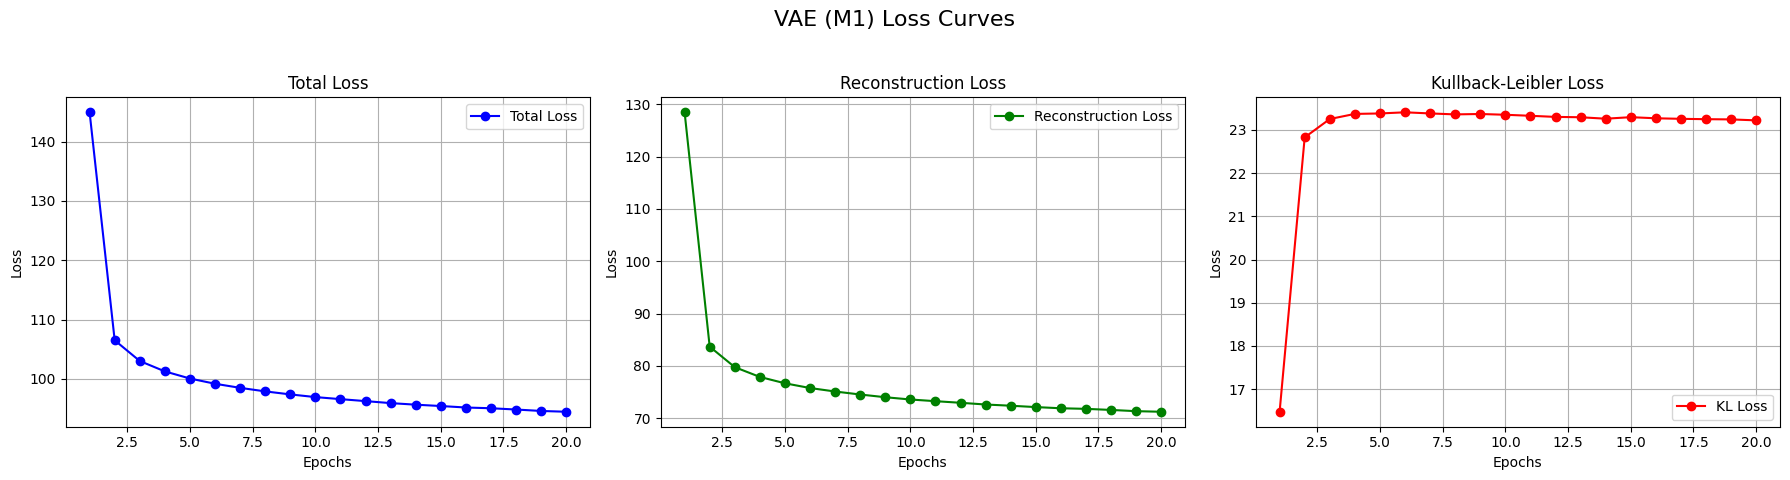

In [235]:
import matplotlib.pyplot as plt

def plot_loss_curves(history):
    """Plots the VAE loss curves from the training history."""
    
    # Extract loss values from the history object
    total_loss = history.history['loss']
    recon_loss = history.history['reconstruction_loss']
    kl_loss = history.history['kl_loss']
    epochs = range(1, len(total_loss) + 1)

    # Create a figure with 3 subplots in a single row
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('VAE (M1) Loss Curves', fontsize=16)

    # Plot Total Loss
    ax1.plot(epochs, total_loss, 'bo-', label='Total Loss')
    ax1.set_title('Total Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot Reconstruction Loss
    ax2.plot(epochs, recon_loss, 'go-', label='Reconstruction Loss')
    ax2.set_title('Reconstruction Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    # Plot KL Loss
    ax3.plot(epochs, kl_loss, 'ro-', label='KL Loss')
    ax3.set_title('Kullback-Leibler Loss')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('Loss')
    ax3.legend()
    ax3.grid(True)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Call the function with the history from your model training
plot_loss_curves(history)

2025-08-15 17:22:06.735621: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


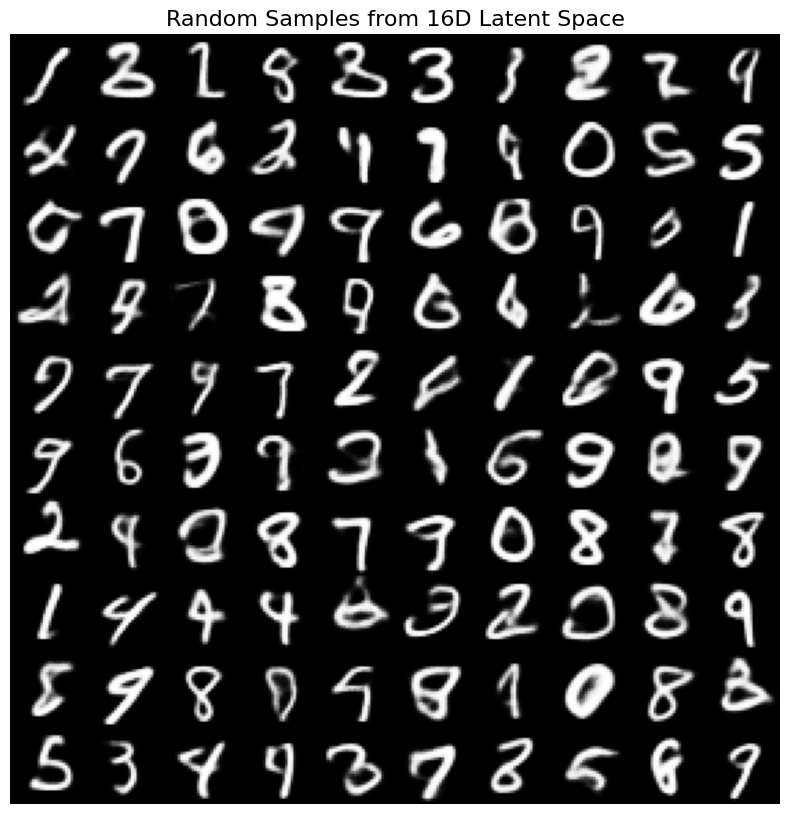

In [236]:
import numpy as np
import matplotlib.pyplot as plt

def plot_randomly_generated_images(decoder, latent_dim, n=10, figsize=10):
    """
    Plots a grid of randomly generated digits for any latent dimension.
    """
    # Create a figure to display the images
    figure = np.zeros((28 * n, 28 * n))
    
    # Iterate over the grid positions
    for i in range(n):
        for j in range(n):
            # Generate a random latent vector from a normal distribution
            z_sample = np.random.normal(size=(1, latent_dim))
            
            # Decode the latent vector to generate an image
            x_decoded = decoder.predict(z_sample, verbose=0)
            
            # Reshape the output to a 28x28 image
            digit = x_decoded[0].reshape(28, 28)
            
            # Place the digit into our display figure
            figure[i * 28 : (i + 1) * 28,
                   j * 28 : (j + 1) * 28] = digit

    # Plot the final figure
    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap="Greys_r")
    plt.axis('off')
    plt.title(f"Random Samples from {latent_dim}D Latent Space", fontsize=16)
    plt.show()

# --- HOW TO USE ---
# Call the new function with your deeper decoder and its latent dimension
plot_randomly_generated_images(decoder, latent_dim)

In [237]:
# Use the encoder to predict the latent space coordinates for the test set
z_mean, _, _ = encoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step


In [238]:
from sklearn.manifold import TSNE

# For better visualization, we'll use a subset of the data
num_samples_to_plot = 5000
indices = np.random.choice(range(len(x_test)), num_samples_to_plot)
test_images_subset = x_test[indices]
test_labels_subset = y_test[indices]

print("Generating latent vectors for the test set...")
# We use z_mean for a stable, deterministic representation of the inputs
z_mean, _, _ = encoder.predict(test_images_subset, verbose=0)

print("Running t-SNE... (This may take a moment)")
tsne = TSNE(n_components=2, perplexity=30.0, max_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(z_mean)

print("t-SNE complete.")

Generating latent vectors for the test set...
Running t-SNE... (This may take a moment)
t-SNE complete.


/tmp/ipykernel_63557/77884607.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap("jet", 10),


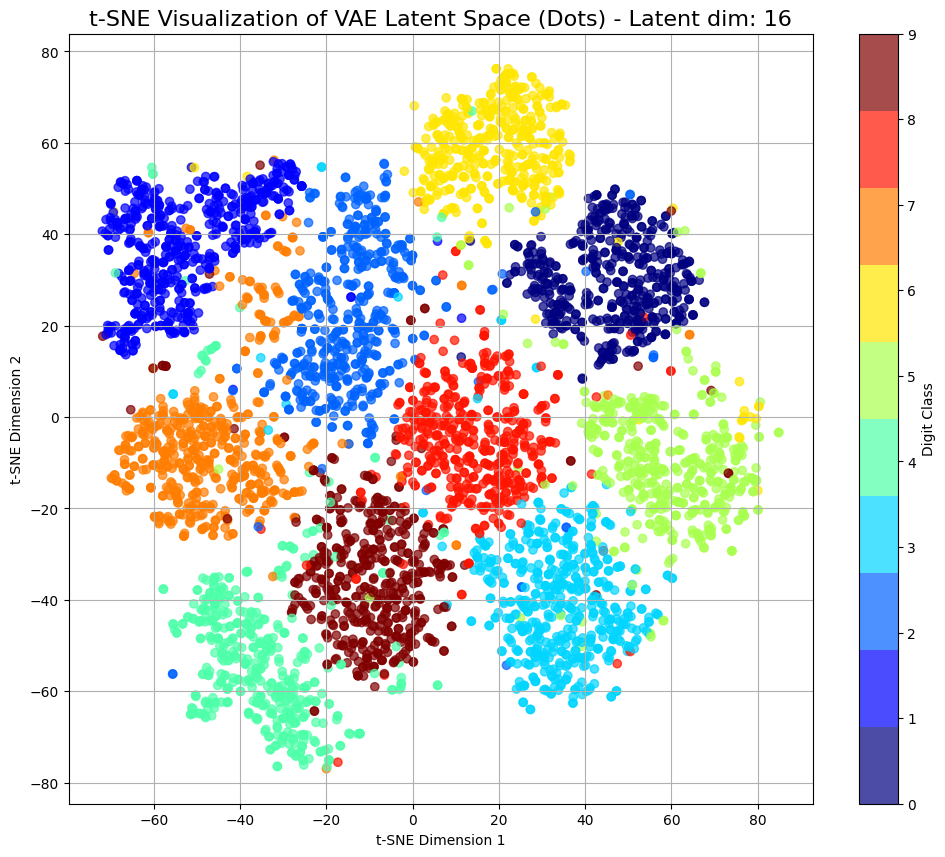

In [239]:
import matplotlib.pyplot as plt

def plot_tsne_scatter(tsne_results, labels):
    """Creates a colored scatter plot of t-SNE results."""
    plt.figure(figsize=(12, 10))
    
    scatter = plt.scatter(
        tsne_results[:, 0], 
        tsne_results[:, 1], 
        c=labels, 
        cmap=plt.cm.get_cmap("jet", 10),
        alpha=0.7
    )
    
    plt.title(f"t-SNE Visualization of VAE Latent Space (Dots) - Latent dim: {latent_dim}", fontsize=16)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    
    # Add a colorbar to identify the digits
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.set_label("Digit Class")
    
    plt.grid(True)
    plt.show()

# Call the plotting function
plot_tsne_scatter(tsne_results, test_labels_subset)

/tmp/ipykernel_63557/2646096650.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap=plt.cm.get_cmap("jet", 10), alpha=0.1)


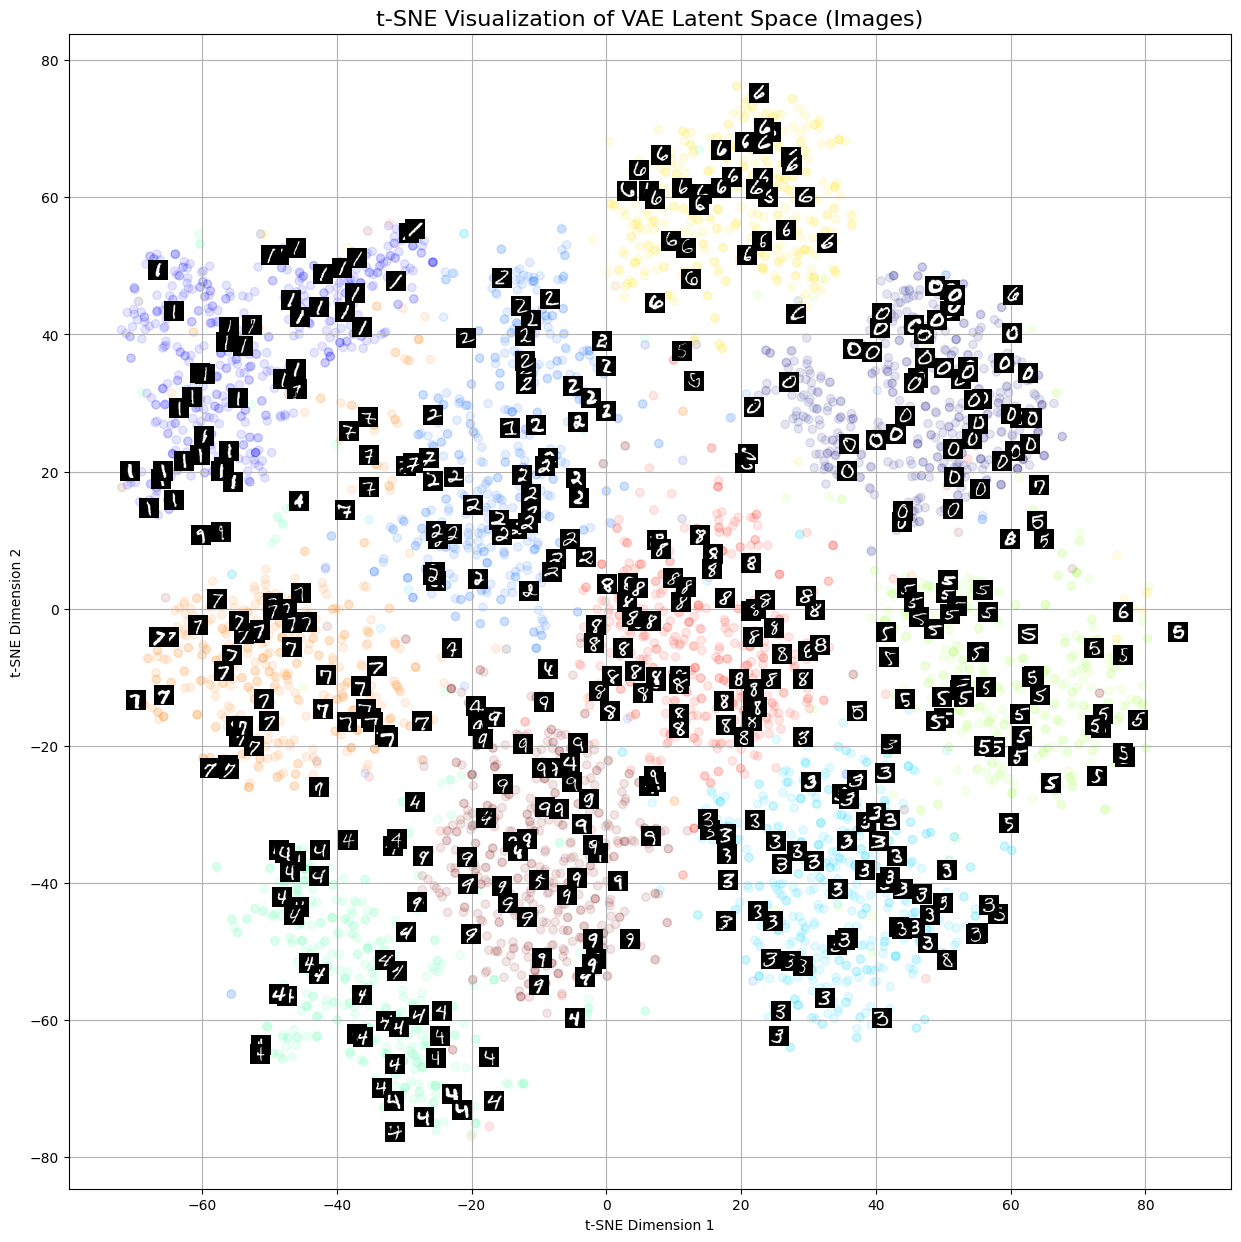

In [240]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def plot_tsne_images(tsne_results, images, labels, zoom=0.5):
    """Creates a t-SNE plot with original images instead of dots."""
    
    fig, ax = plt.subplots(figsize=(15, 15))
    ax.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap=plt.cm.get_cmap("jet", 10), alpha=0.1)
    
    # Plot a subset of images to avoid clutter
    # You can increase this number, but it will get crowded
    num_images_to_show = 500
    indices = np.random.choice(range(len(images)), num_images_to_show)

    for i in indices:
        x, y = tsne_results[i, :]
        img = images[i].reshape(28, 28)
        
        # Use OffsetImage to create an image box
        im = OffsetImage(img, cmap='gray', zoom=zoom)
        
        # Use AnnotationBbox to place the image at the coordinate
        ab = AnnotationBbox(im, (x, y), frameon=False, pad=0.0)
        ax.add_artist(ab)
        
    ax.set_title("t-SNE Visualization of VAE Latent Space (Images)", fontsize=16)
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.grid(True)
    plt.show()

# Call the plotting function
# We pass the original `test_images_subset` for the thumbnails
plot_tsne_images(tsne_results, test_images_subset, test_labels_subset)

In [242]:
import os

# Create a directory to save the models
model_dir = "../../models/vae/"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the encoder and decoder models
encoder.save(os.path.join(model_dir, "m1_encoder.keras"))
decoder.save(os.path.join(model_dir, "m1_decoder.keras"))

print(f"Encoder and Decoder models saved to the '{model_dir}' directory.")

Encoder and Decoder models saved to the '../../models/vae/' directory.
